In [1]:
!pip install torch torchvision torchaudio --quiet
!pip install matplotlib numpy scikit-learn lime shap opencv-python --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shap

from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 30
NUM_CLASSES = 10
MODEL_PATH = "best_cifar10_cnn.pth"

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# U-normalisering for plotting
def denormalize(img_tensor):
    img = img_tensor.clone().cpu()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    img = torch.clamp(img, 0, 1)
    return img

In [6]:
train_dataset_full = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

# Split train -> train + val
train_size = int(0.9 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

# Viktig: val skal ikke ha random augmentations
val_dataset.dataset = copy.deepcopy(train_dataset_full)
val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Files already downloaded and verified
Files already downloaded and verified
Train size: 45000
Val size: 5000
Test size: 10000


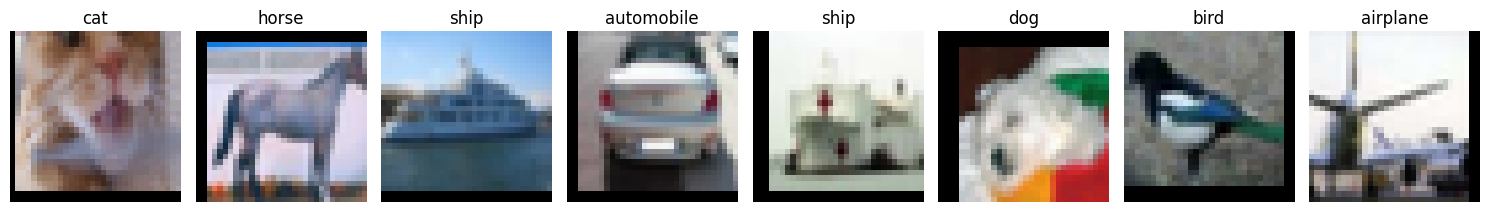

In [7]:
def show_batch(loader, class_names, n=8):
    images, labels = next(iter(loader))
    plt.figure(figsize=(15, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, CLASS_NAMES, n=8)

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 16x16
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 8x8
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)                               # 4x4
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("Best validation accuracy:", best_val_acc)

Epoch [1/30] | Train Loss: 1.5093 | Train Acc: 0.4428 | Val Loss: 1.1931 | Val Acc: 0.5652
Epoch [2/30] | Train Loss: 1.1296 | Train Acc: 0.5990 | Val Loss: 0.9803 | Val Acc: 0.6546
Epoch [3/30] | Train Loss: 0.9506 | Train Acc: 0.6666 | Val Loss: 0.8329 | Val Acc: 0.6970
Epoch [4/30] | Train Loss: 0.8478 | Train Acc: 0.7062 | Val Loss: 0.8256 | Val Acc: 0.7154
Epoch [5/30] | Train Loss: 0.7657 | Train Acc: 0.7383 | Val Loss: 0.6693 | Val Acc: 0.7658
Epoch [6/30] | Train Loss: 0.7076 | Train Acc: 0.7574 | Val Loss: 0.6313 | Val Acc: 0.7842
Epoch [7/30] | Train Loss: 0.6597 | Train Acc: 0.7758 | Val Loss: 0.7365 | Val Acc: 0.7462
Epoch [8/30] | Train Loss: 0.6302 | Train Acc: 0.7866 | Val Loss: 0.6108 | Val Acc: 0.7824
Epoch [9/30] | Train Loss: 0.5888 | Train Acc: 0.8028 | Val Loss: 0.5531 | Val Acc: 0.8110
Epoch [10/30] | Train Loss: 0.5643 | Train Acc: 0.8108 | Val Loss: 0.6683 | Val Acc: 0.7774
Epoch [11/30] | Train Loss: 0.5361 | Train Acc: 0.8192 | Val Loss: 0.5239 | Val Acc: 0.81

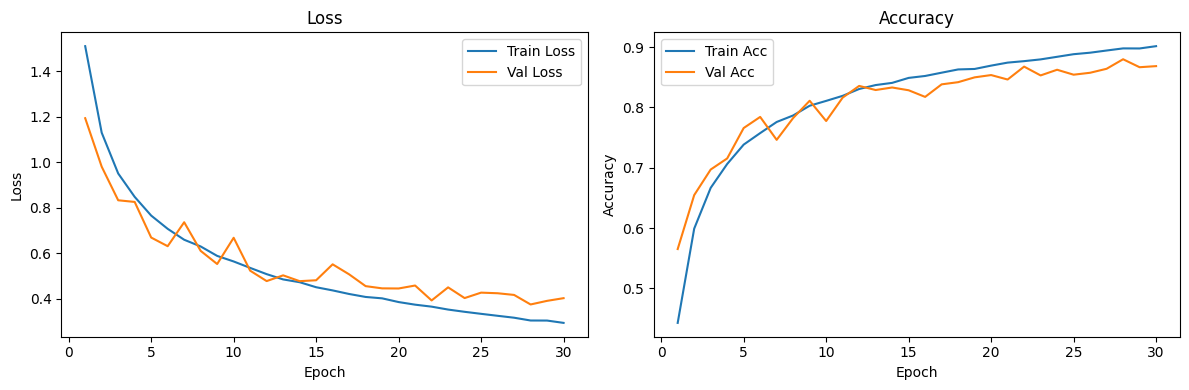

In [11]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))

Test Loss: 0.4134
Test Accuracy: 0.8663


In [13]:
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

    airplane       0.83      0.90      0.86      1000
  automobile       0.96      0.92      0.94      1000
        bird       0.85      0.77      0.81      1000
         cat       0.74      0.75      0.75      1000
        deer       0.82      0.90      0.86      1000
         dog       0.81      0.82      0.81      1000
        frog       0.89      0.91      0.90      1000
       horse       0.93      0.88      0.90      1000
        ship       0.95      0.89      0.92      1000
       truck       0.92      0.93      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [14]:
@torch.no_grad()
def predict_tensor(model, image_tensor):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    outputs = model(image_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_class = probs.argmax(dim=1).item()
    confidence = probs[0, pred_class].item()
    return pred_class, confidence, probs[0].cpu().numpy()

In [15]:
def collect_predictions(model, dataset, max_items=200):
    model.eval()
    results = []
    
    for i in range(min(len(dataset), max_items)):
        image, label = dataset[i]
        pred, conf, probs = predict_tensor(model, image)
        results.append({
            "index": i,
            "image": image,
            "true": label,
            "pred": pred,
            "conf": conf
        })
    return results

results = collect_predictions(model, test_dataset, max_items=300)

correct_examples = [r for r in results if r["true"] == r["pred"]]
wrong_examples = [r for r in results if r["true"] != r["pred"]]

print("Correct:", len(correct_examples))
print("Wrong:", len(wrong_examples))

Correct: 267
Wrong: 33


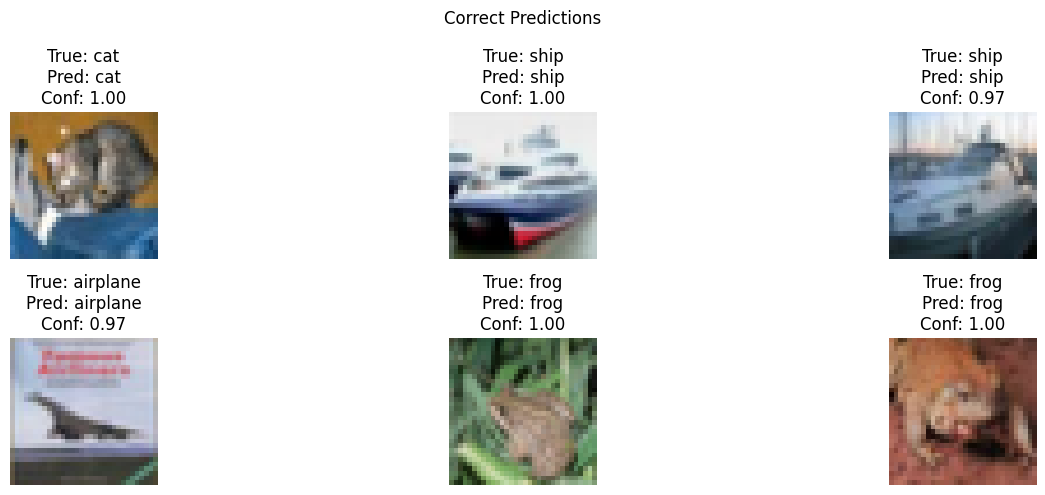

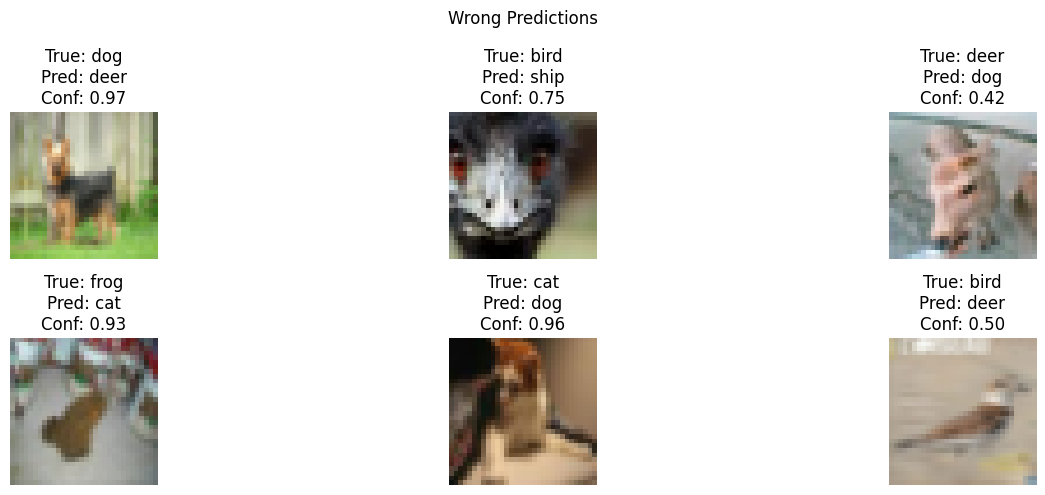

In [16]:
def show_examples(examples, title, n=6):
    plt.figure(figsize=(15, 5))
    for i, ex in enumerate(examples[:n]):
        plt.subplot(2, 3, i + 1)
        img = denormalize(ex["image"]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"True: {CLASS_NAMES[ex['true']]}\nPred: {CLASS_NAMES[ex['pred']]}\nConf: {ex['conf']:.2f}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(correct_examples, "Correct Predictions", n=6)
show_examples(wrong_examples, "Wrong Predictions", n=6)

In [17]:
last_conv_layer = model.features[14]  # siste Conv2d-lag i denne modellen
print(last_conv_layer)

Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(device)
        
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        loss = output[:, target_class]
        loss.backward()
        
        gradients = self.gradients[0]      # [C, H, W]
        activations = self.activations[0]  # [C, H, W]
        
        weights = gradients.mean(dim=(1, 2))  # [C]
        cam = torch.zeros(activations.shape[1:], device=device)
        
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        cam = F.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        
        cam = cam.cpu().numpy()
        return cam, target_class

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

In [19]:
def overlay_heatmap_on_image(image_tensor, cam, alpha=0.4):
    img = denormalize(image_tensor).permute(1, 2, 0).numpy()
    img = np.uint8(img * 255)

    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * cam_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return img, overlay

def show_gradcam(example):
    gradcam = GradCAM(model, last_conv_layer)
    cam, target_class = gradcam.generate(example["image"], target_class=example["pred"])
    gradcam.remove_hooks()
    
    original, overlay = overlay_heatmap_on_image(example["image"], cam)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(f"Original\nTrue: {CLASS_NAMES[example['true']]}\nPred: {CLASS_NAMES[example['pred']]}")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

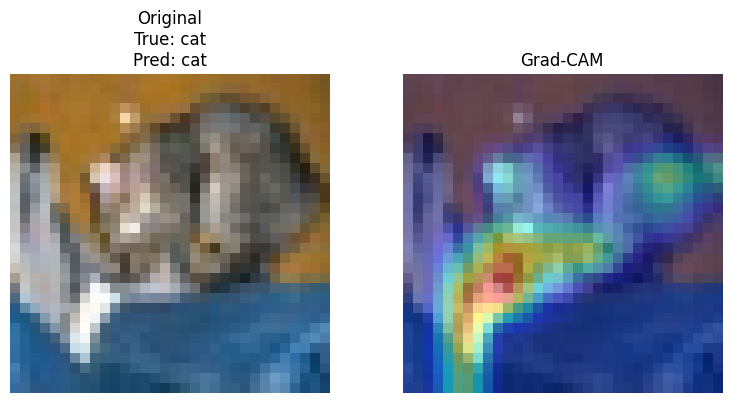

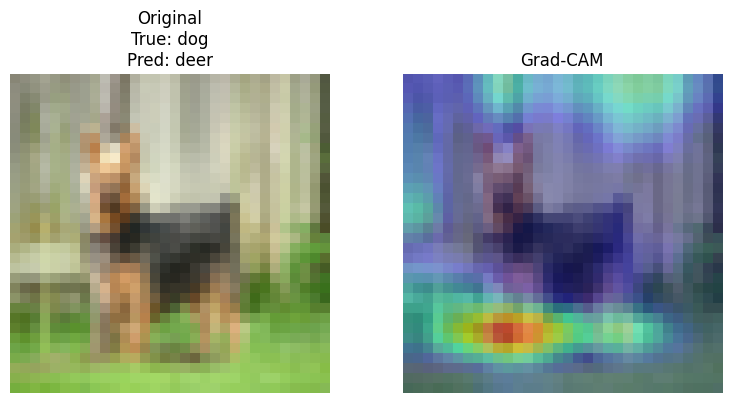

In [20]:
show_gradcam(correct_examples[0])
show_gradcam(wrong_examples[0])

In [21]:
def occlusion_sensitivity(model, image_tensor, target_class=None, patch_size=4, stride=2):
    model.eval()
    image = image_tensor.clone().to(device)
    
    with torch.no_grad():
        base_output = model(image.unsqueeze(0))
        base_probs = torch.softmax(base_output, dim=1)
        if target_class is None:
            target_class = base_probs.argmax(dim=1).item()
    
    _, _, H, W = image.unsqueeze(0).shape
    heatmap = np.zeros((H, W), dtype=np.float32)
    
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = image.clone()
            occluded[:, y:y+patch_size, x:x+patch_size] = 0.0
            
            with torch.no_grad():
                output = model(occluded.unsqueeze(0))
                probs = torch.softmax(output, dim=1)
                score = probs[0, target_class].item()
            
            heatmap[y:y+patch_size, x:x+patch_size] += (base_probs[0, target_class].item() - score)
    
    heatmap -= heatmap.min()
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    
    return heatmap, target_class

In [22]:
def show_occlusion(example):
    heatmap, target_class = occlusion_sensitivity(
        model, example["image"], target_class=example["pred"], patch_size=4, stride=2
    )
    
    original, overlay = overlay_heatmap_on_image(example["image"], heatmap)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(f"Original\nTrue: {CLASS_NAMES[example['true']]}\nPred: {CLASS_NAMES[example['pred']]}")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Occlusion Sensitivity")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

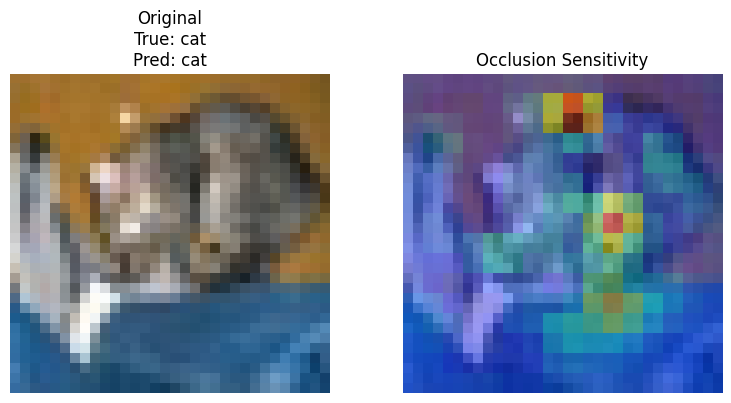

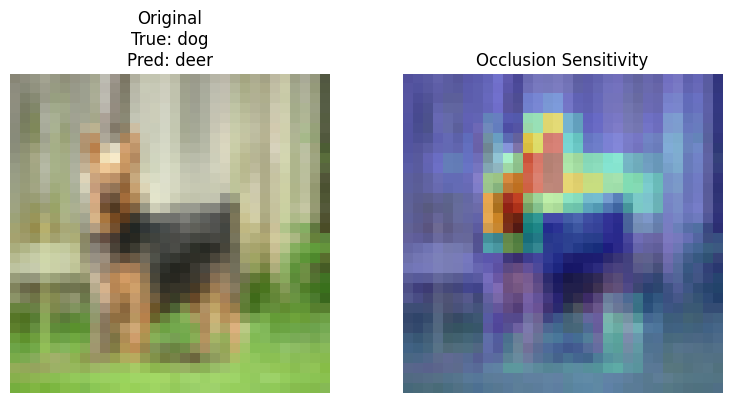

In [23]:
show_occlusion(correct_examples[0])
show_occlusion(wrong_examples[0])

In [24]:
def tensor_to_numpy_image(image_tensor):
    img = denormalize(image_tensor).permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

def preprocess_numpy_images(images_np):
    # images_np: [N, H, W, C], verdier 0..1
    tensors = []
    for img in images_np:
        img_t = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
        for c in range(3):
            img_t[c] = (img_t[c] - mean[c]) / std[c]
        tensors.append(img_t)
    return torch.stack(tensors).to(device)

def batch_predict(images_np):
    model.eval()
    images_t = preprocess_numpy_images(images_np)
    with torch.no_grad():
        outputs = model(images_t)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

In [25]:
def show_lime_explanation(example, num_samples=1000):
    image_np = tensor_to_numpy_image(example["image"])
    
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image_np,
        classifier_fn=batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=num_samples
    )
    
    temp, mask = explanation.get_image_and_mask(
        label=example["pred"],
        positive_only=True,
        num_features=6,
        hide_rest=False
    )
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.title(f"Original\nTrue: {CLASS_NAMES[example['true']]}\nPred: {CLASS_NAMES[example['pred']]}")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME Explanation")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

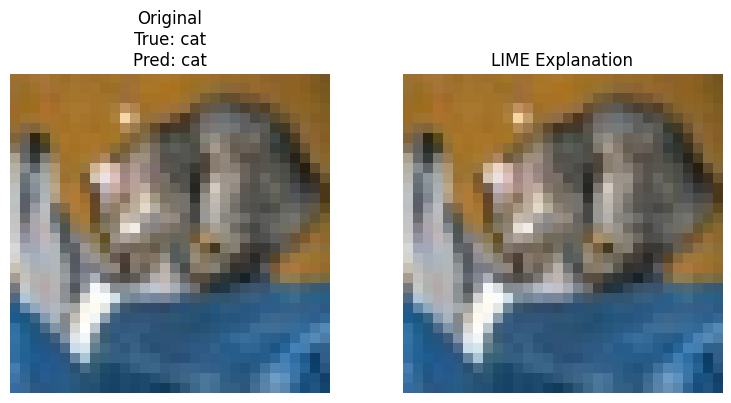

  0%|          | 0/1000 [00:00<?, ?it/s]

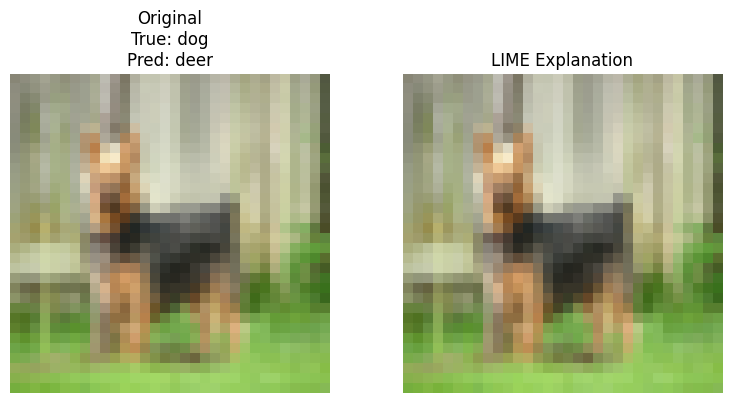

In [26]:
show_lime_explanation(correct_examples[0], num_samples=1000)
show_lime_explanation(wrong_examples[0], num_samples=1000)

In [27]:
# Velg noen bakgrunnsbilder
background_images = []
for i in range(20):
    background_images.append(tensor_to_numpy_image(test_dataset[i][0]))
background_images = np.array(background_images)

# Velg noen bilder som skal forklares
explain_images = np.array([
    tensor_to_numpy_image(correct_examples[0]["image"]),
    tensor_to_numpy_image(wrong_examples[0]["image"])
])

print("Background shape:", background_images.shape)
print("Explain shape:", explain_images.shape)

Background shape: (20, 32, 32, 3)
Explain shape: (2, 32, 32, 3)


In [28]:
masker = shap.maskers.Image("inpaint_telea", explain_images[0].shape)
explainer = shap.Explainer(batch_predict, masker)

shap_values = explainer(
    explain_images,
    max_evals=500,
    batch_size=20
)

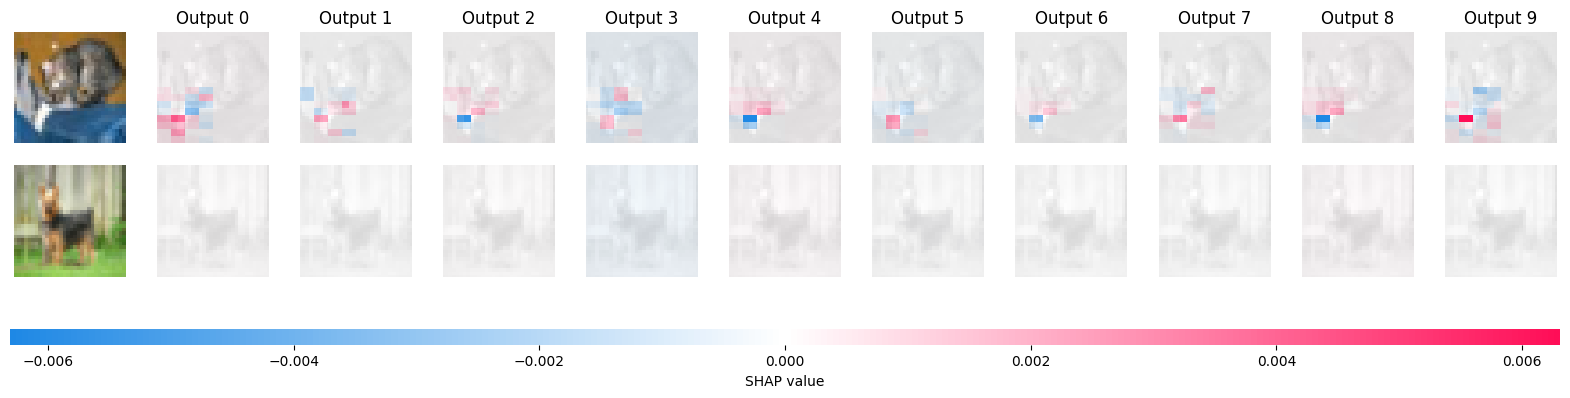

In [29]:
shap.image_plot(shap_values)

Correct example:
True: cat | Pred: cat


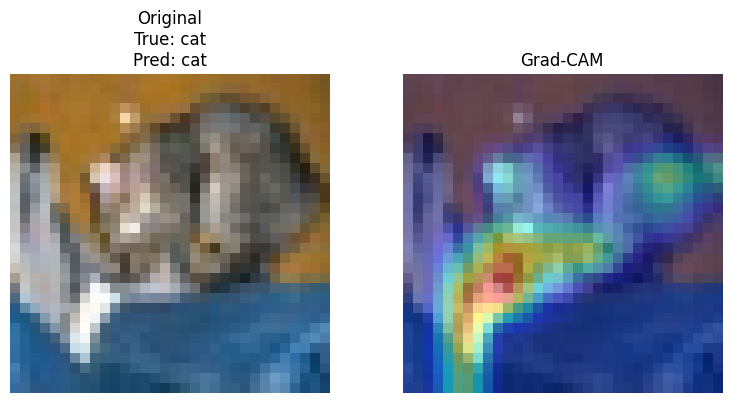

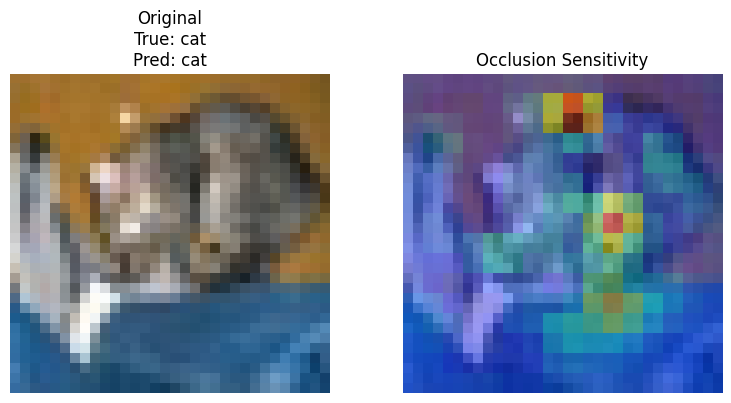

  0%|          | 0/1000 [00:00<?, ?it/s]

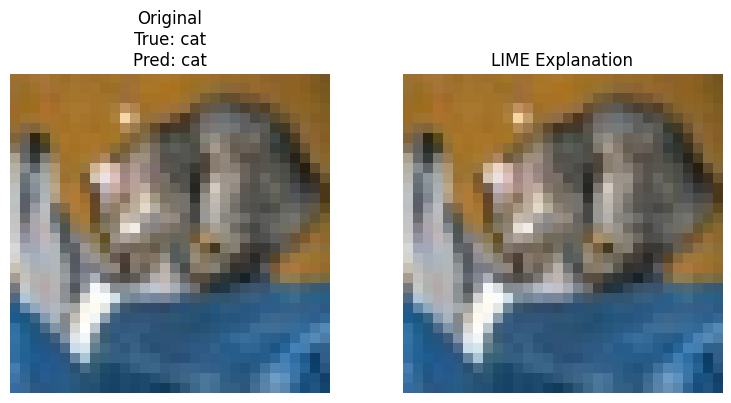

Wrong example:
True: dog | Pred: deer


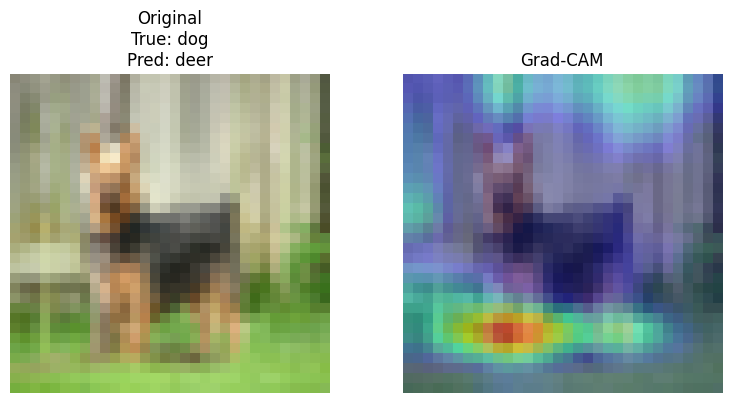

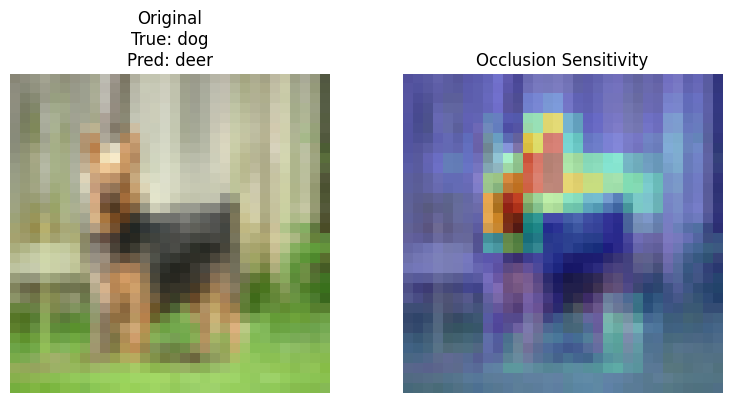

  0%|          | 0/1000 [00:00<?, ?it/s]

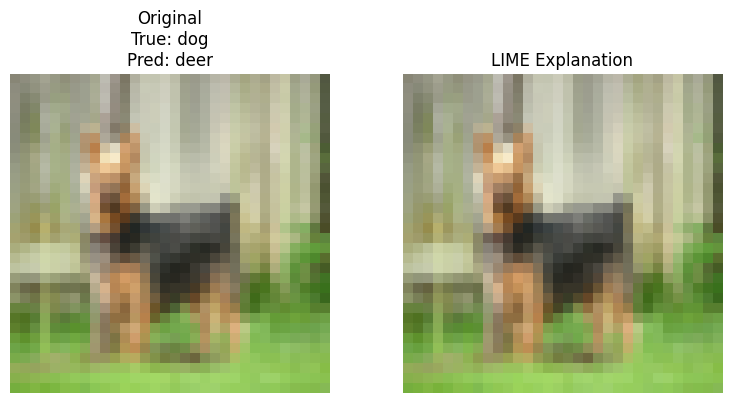

In [30]:
correct_ex = correct_examples[0]
wrong_ex = wrong_examples[0]

print("Correct example:")
print("True:", CLASS_NAMES[correct_ex["true"]], "| Pred:", CLASS_NAMES[correct_ex["pred"]])

show_gradcam(correct_ex)
show_occlusion(correct_ex)
show_lime_explanation(correct_ex, num_samples=1000)

print("Wrong example:")
print("True:", CLASS_NAMES[wrong_ex["true"]], "| Pred:", CLASS_NAMES[wrong_ex["pred"]])

show_gradcam(wrong_ex)
show_occlusion(wrong_ex)
show_lime_explanation(wrong_ex, num_samples=1000)

In [31]:
os.makedirs("outputs", exist_ok=True)
print("Folder 'outputs' created.")

Folder 'outputs' created.


In [32]:
def save_gradcam(example, filename):
    gradcam = GradCAM(model, last_conv_layer)
    cam, _ = gradcam.generate(example["image"], target_class=example["pred"])
    gradcam.remove_hooks()
    
    original, overlay = overlay_heatmap_on_image(example["image"], cam)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close()

save_gradcam(correct_examples[0], "outputs/gradcam_correct.png")
save_gradcam(wrong_examples[0], "outputs/gradcam_wrong.png")
print("Saved Grad-CAM images.")

Saved Grad-CAM images.


In [33]:
def save_occlusion(example, filename):
    heatmap, _ = occlusion_sensitivity(
        model, example["image"], target_class=example["pred"], patch_size=4, stride=2
    )
    original, overlay = overlay_heatmap_on_image(example["image"], heatmap)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Occlusion")
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close()

save_occlusion(correct_examples[0], "outputs/occlusion_correct.png")
save_occlusion(wrong_examples[0], "outputs/occlusion_wrong.png")
print("Saved Occlusion images.")

Saved Occlusion images.
